## Time-Series Delay Embeddings and Persistent Homology
This notebook studies the process required for converting one-dimensionsal time-series data into point clouds using delay embeddings, and how to analyze the corresponding structure using persistent homology. 
The goal is to establish benchmark examples for the classification of time series via Topological Data Analysis techniques.

## 1. Clean Periodic Signal 
We begin with a simple periodic time series (Sine wave), and study how the temporal structure is transformed into geomteric structure via a delay embedding, allowing us to study its persistent homology features.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

## Sine Wave

In [4]:
t = np.linspace(0, 10*np.pi, 500, endpoint = False)
clean_signal = np.sin(t)

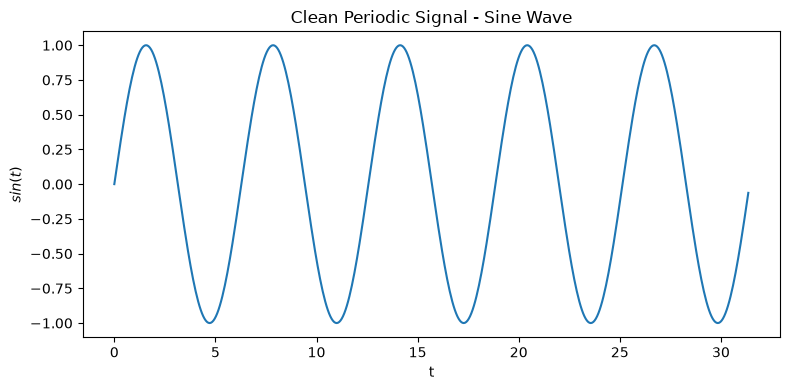

In [16]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(t, clean_signal)
ax.set_title("Clean Periodic Signal - Sine Wave")
ax.set_xlabel("t")
ax.set_ylabel("$sin(t)$")

fig.tight_layout()
plt.show()

To turn the time-series' temporal structure into its correspoding two-dimesnional geometric structure, we are going to use a delay embedding. This consists in associating the points of the time series to 2D vectors of the form $X_i = (x_i,\, x_{\tau +i})$, by pairing each value to its value $\tau$ samples later.
As we are working with a sine-wave function, using a quarter-period delay ($\tau = 25$), yields the following:

$sin(t+\frac{\pi}{2}) = cos(t)$,

so the delay-embadding points become $(sin(t), \, cos(t))$.

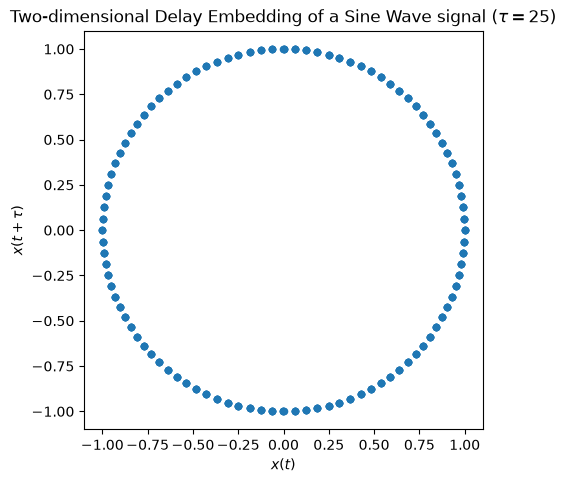

In [29]:
tau = 25
clean_embedding = np.column_stack((clean_signal[:-tau],
                                 clean_signal[tau:])
                                 )

fig_2, ax_2 = plt.subplots(figsize = (5, 5))
ax_2.scatter(clean_embedding[:, 0],
            clean_embedding[:, 1],
            s = 20,
            )
ax_2.set_title("Two-dimensional Delay Embedding of a Sine Wave signal ($\\tau = 25$)")
ax_2.set_xlabel("$x(t)$")
ax_2.set_ylabel("$x(t+\\tau)$")
ax_2.set_aspect("equal")

fig_2.tight_layout()
plt.show()